### Multiple Linear Regression

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [36]:
df = pd.read_csv('../0-Dataset/economic_index.csv')
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [37]:
### Drop unneccessary columns
df.drop(columns = ['Unnamed: 0', 'year', 'month'], axis=1, inplace=True)

In [38]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [39]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

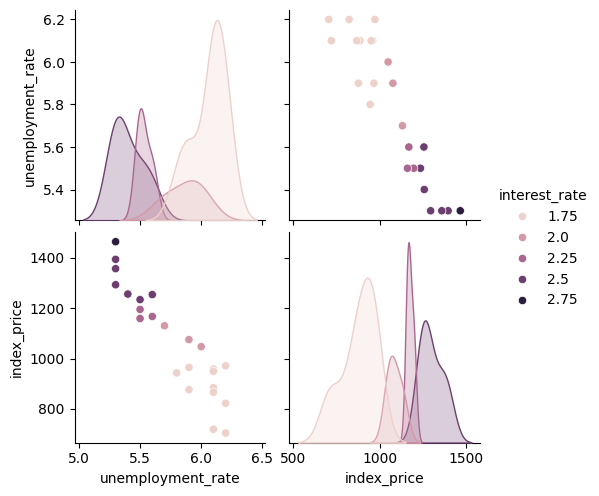

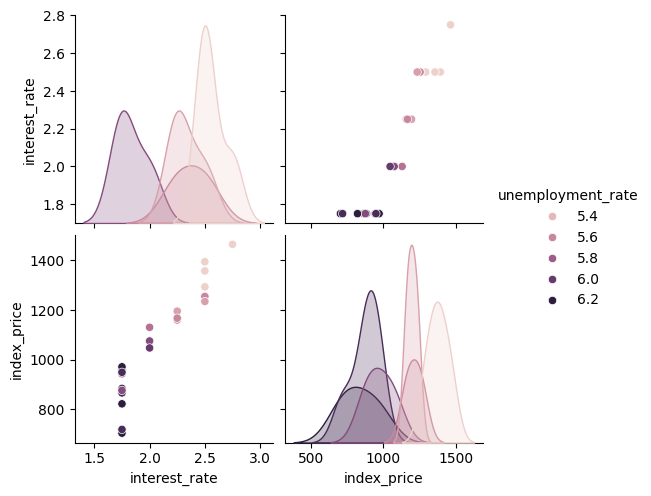

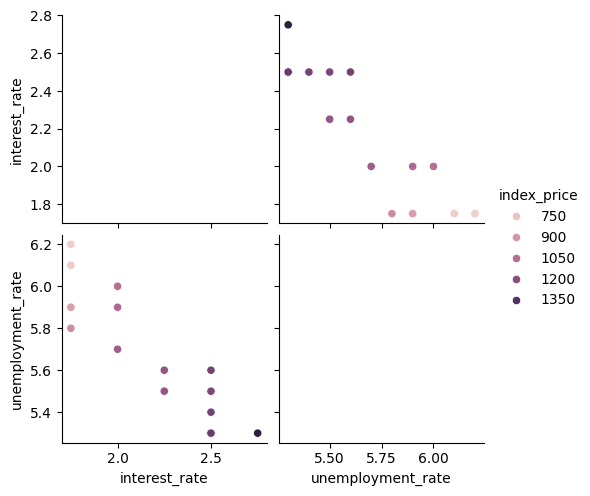

In [40]:
### Lets do some visualization
for column in df.columns:
        sns.pairplot(df, hue=column)

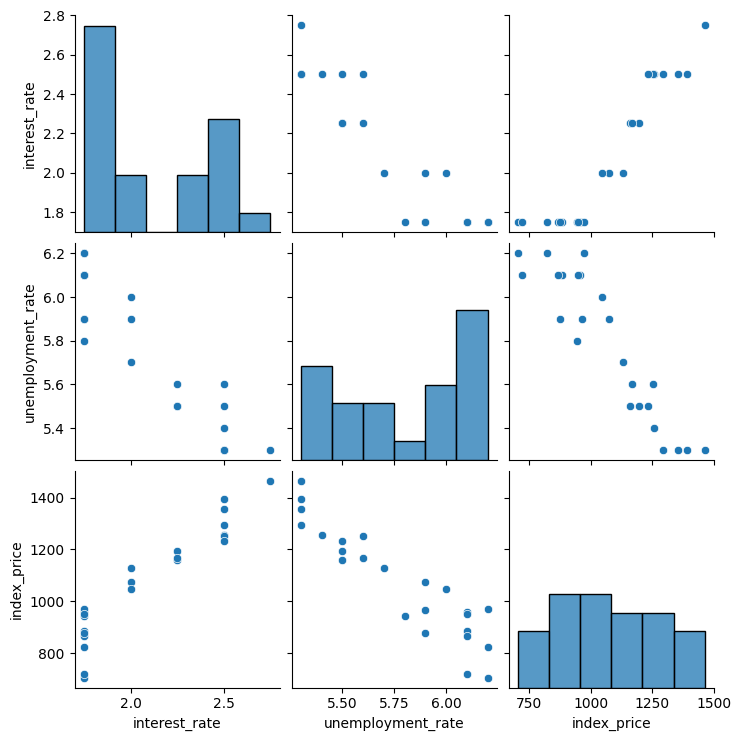

In [41]:
sns.pairplot(df)

In [42]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


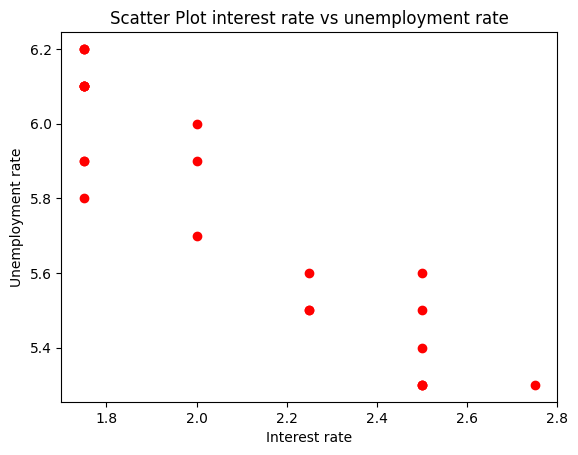

In [43]:
### Visualize the datapoint more closely
plt.scatter(df['interest_rate'], df['unemployment_rate'], color='r')
plt.title('Scatter Plot interest rate vs unemployment rate')
plt.xlabel('Interest rate')
plt.ylabel('Unemployment rate')
plt.show()
plt.close()

In [44]:
### Independent and Dependent features
X = df.iloc[:, :-1] ## it says that take all the columns except last one
y = df.iloc[:,-1] ## it says that take only last columns

In [45]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [46]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [48]:
X_test.shape, X_train.shape, y_train.shape, y_test.shape

((6, 2), (18, 2), (18,), (6,))

<Axes: xlabel='interest_rate', ylabel='index_price'>

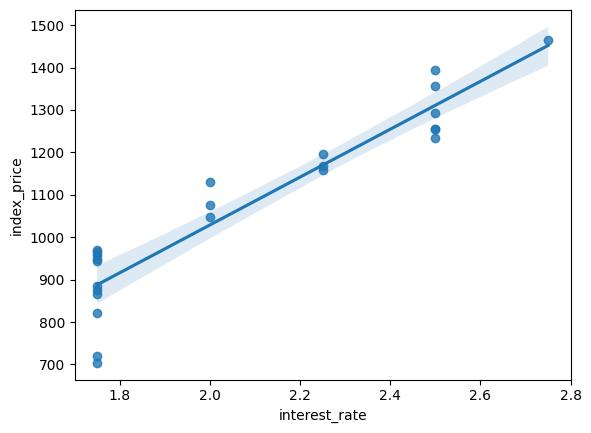

In [49]:
sns.regplot(x='interest_rate', y='index_price', data=df)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

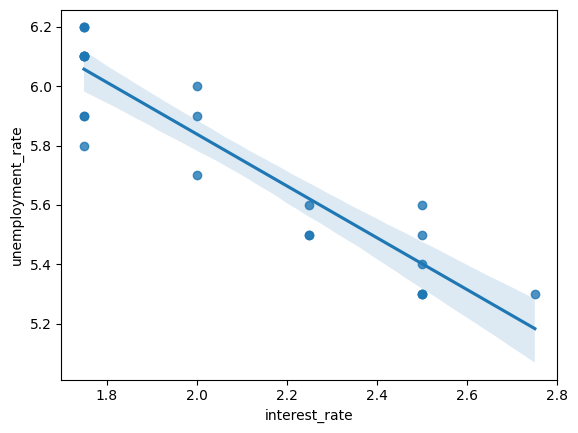

In [50]:
sns.regplot(x='interest_rate', y='unemployment_rate', data=df)

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

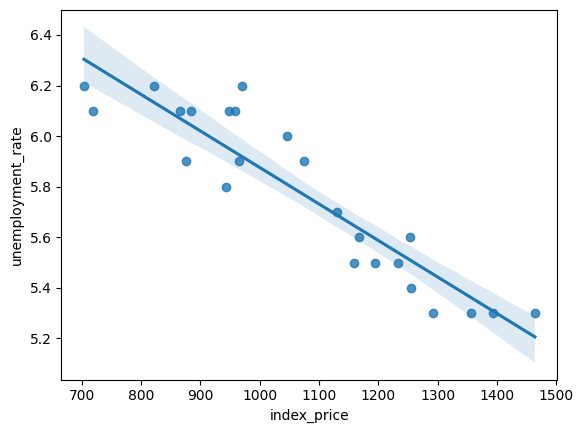

In [51]:
sns.regplot(x='index_price', y='unemployment_rate', data=df)

In [52]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [53]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [54]:
regression = LinearRegression()
regression.fit(X_train, y_train)

LinearRegression()

#### Cross Validation 

sklearn.model_selection.cross_validate(estimator, X, y, scoring, cv)
Here when we are going for the cross validation then it is taking the parameters of estimator that is nothing but our model then we give the X and Y values and then for the error calculation we use the scoring="error-type" and then use the cross validation for the no of iterations for testing and training the datasets

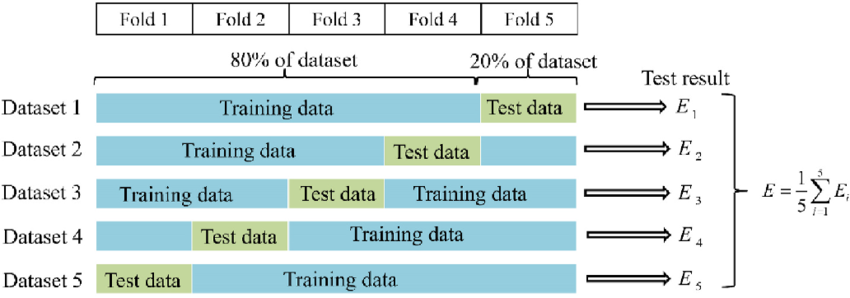

Iterations:
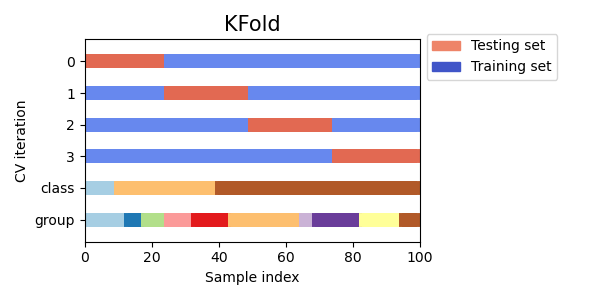

In [55]:
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression, X_train, y_train, scoring='neg_mean_squared_error', cv=5)

In [56]:
validation_score

array([-1861.74046551, -8715.8459466 , -7707.52362191, -9169.13776461,
        -791.32842311])

In [57]:
np.mean(validation_score)

-5649.115244350756

#### Prediction

In [58]:
y_pred = regression.predict(X_test)

In [59]:
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Mean Squared Error: ", mse)
print("Mean Absolute Error: ", mae)
print("Root Mean Squared Error: ", rmse)

Mean Squared Error:  5793.762887712569
Mean Absolute Error:  59.935781523235484
Root Mean Squared Error:  76.11677139574805


### Assumptions

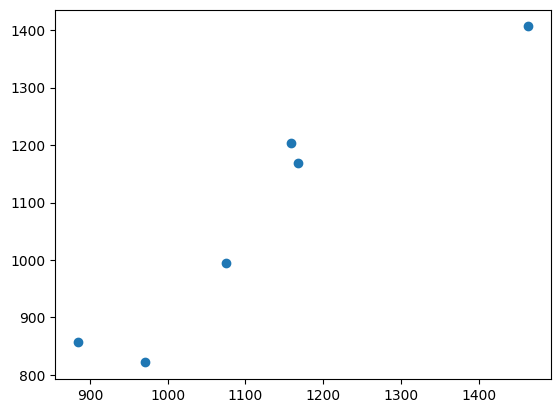

In [61]:
plt.scatter(y_test, y_pred)

In [62]:
residuals = y_test-y_pred
residuals

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64

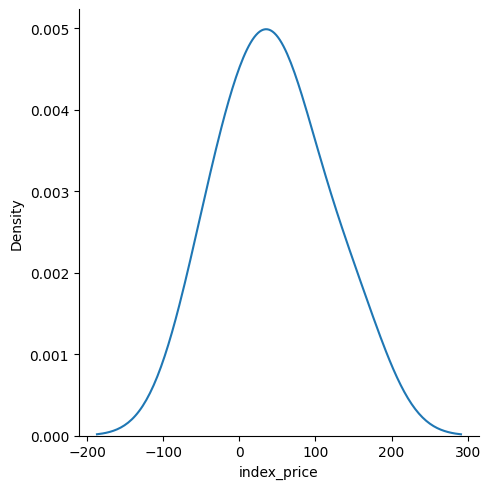

In [63]:
sns.displot(residuals, kind = 'kde')

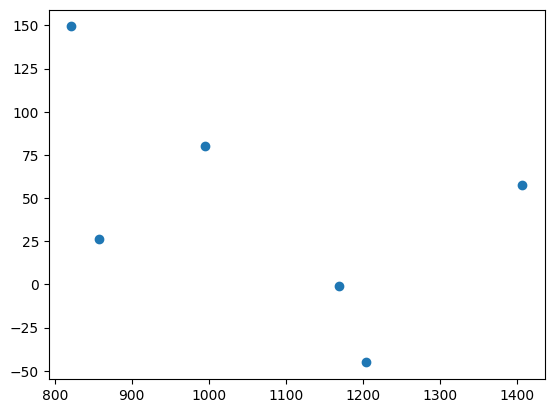

In [64]:
### Scatter plot wrt prediction and residuals

plt.scatter(y_pred, residuals)

In [65]:
regression.intercept_

1053.4444444444443

In [66]:
regression.coef_

array([  88.27275507, -116.25716066])

In [67]:
import statsmodels.api as sm
model = sm.OLS(y_train, X_train).fit()

In [68]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Fri, 01 Aug 2025   Prob (F-statistic):                       0.754
Time:                        23:06:18   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------